## Plotting ETF Historical Prices

In [1]:
# Install yfinance if not already installed
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Downloading historical data for AIQ and AIEQ

In [7]:
tickers = ["AIQ", "AIEQ", "SPYM"]
data = yf.download(tickers, period="max")

display(data.head())

/tmp/ipykernel_2618/3040290205.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="max")
[*********************100%***********************]  3 of 3 completed


Price      Close               High                Low               Open      \
Ticker      AIEQ AIQ      SPYM AIEQ AIQ      SPYM AIEQ AIQ      SPYM AIEQ AIQ   
Date                                                                            
2005-11-15   NaN NaN  9.766092  NaN NaN  9.766092  NaN NaN  9.719718  NaN NaN   
2005-11-16   NaN NaN  9.702542  NaN NaN  9.702542  NaN NaN  9.661320  NaN NaN   
2005-11-17   NaN NaN  9.702542  NaN NaN  9.702542  NaN NaN  9.702542  NaN NaN   
2005-11-18   NaN NaN  9.831363  NaN NaN  9.831363  NaN NaN  9.831363  NaN NaN   
2005-11-21   NaN NaN  9.870866  NaN NaN  9.870866  NaN NaN  9.815904  NaN NaN   

Price                Volume             
Ticker          SPYM   AIEQ AIQ   SPYM  
Date                                    
2005-11-15  9.755787    NaN NaN  36000  
2005-11-16  9.661320    NaN NaN  80000  
2005-11-17  9.702542    NaN NaN      0  
2005-11-18  9.831363    NaN NaN    800  
2005-11-21  9.815904    NaN NaN   8000

In [9]:
# Find the first date where AIEQ has valid 'Close' data
aieq_start_date = data[('Close', 'AIEQ')].first_valid_index()
print(f"AIEQ's first valid data point is from: {aieq_start_date}")

# Filter the data to start from AIEQ's first valid date
filtered_data = data[data.index >= aieq_start_date]

display(filtered_data.head())

AIEQ's first valid data point is from: 2017-10-18 00:00:00


Price           Close                      High                       Low      \
Ticker           AIEQ AIQ       SPYM       AIEQ AIQ       SPYM       AIEQ AIQ   
Date                                                                            
2017-10-18  21.809603 NaN  26.063995  21.833807 NaN  26.168216  21.671294 NaN   
2017-10-19  21.857143 NaN  26.055304  22.042996 NaN  26.055304  21.619425 NaN   
2017-10-20  21.947912 NaN  26.185587  22.138088 NaN  26.246382  21.913336 NaN   
2017-10-23  21.757734 NaN  26.098736  22.466568 NaN  26.298494  21.705869 NaN   
2017-10-24  21.775024 NaN  26.133474  21.852823 NaN  26.229011  21.767244 NaN   

Price                       Open                    Volume              
Ticker           SPYM       AIEQ AIQ       SPYM       AIEQ AIQ    SPYM  
Date                                                                    
2017-10-18  26.046625  21.766382 NaN  26.168216   149500.0 NaN   49200  
2017-10-19  25.925027  22.042996 NaN  26.046618   198400.0 NaN   24300  
2017-10-20  26.133477  22.138088 NaN  26.142162   592700.0 NaN  164900  
2017-10-23  26.090052  22.449279 NaN  26.298494  1762100.0 NaN   65500  
2017-10-24  26.116104  21.800956 NaN  26.229011   546200.0 NaN   85500

### Plotting the adjusted close prices from AIEQ's start date

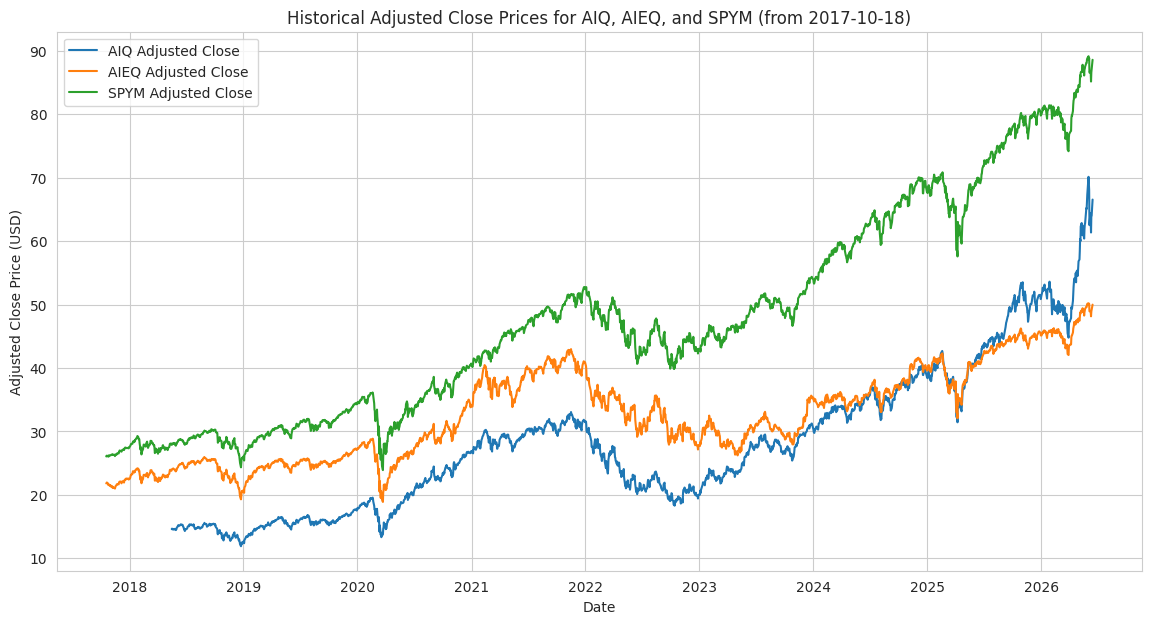

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(filtered_data[('Close', 'AIQ')], label='AIQ Adjusted Close')
plt.plot(filtered_data[('Close', 'AIEQ')], label='AIEQ Adjusted Close')
plt.plot(filtered_data[('Close', 'SPYM')], label='SPYM Adjusted Close')

plt.title(f'Historical Adjusted Close Prices for AIQ, AIEQ, and SPYM (from {aieq_start_date.strftime('%Y-%m-%d')})')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### Plotting the adjusted close prices

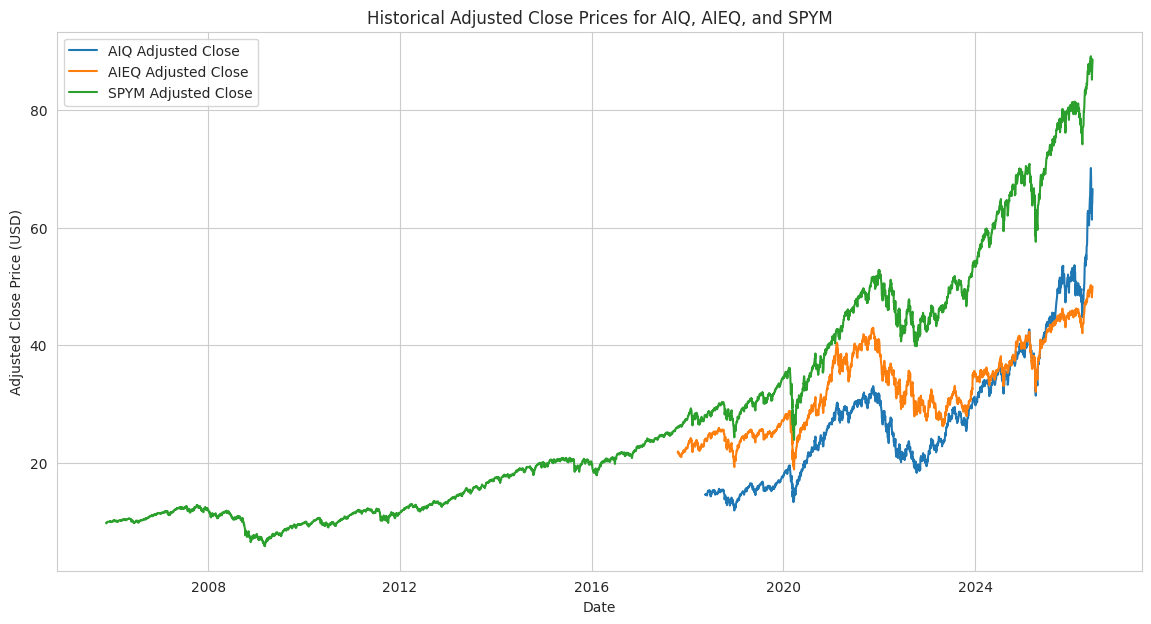

In [8]:
plt.figure(figsize=(14, 7))
plt.plot(data[('Close', 'AIQ')], label='AIQ Adjusted Close')
plt.plot(data[('Close', 'AIEQ')], label='AIEQ Adjusted Close')
plt.plot(data[('Close', 'SPYM')], label='SPYM Adjusted Close')

plt.title('Historical Adjusted Close Prices for AIQ, AIEQ, and SPYM')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()